In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import networkx as nx
import simulator_fn
from simulator_fn import *
# from fitness_fn_simple import get_metrics
# from simple_optimization import *

In [2]:
exec_idx = "5"

In [3]:
best_solution = np.load(f"./solutions/best_solution-{exec_idx}.npy")
best_solution

array([[[  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,   0.,  -8., -18., -13.],
        [  0.,   0.,   0.,   0.,   0.,  13.,  13.,  13.],
        [  0.,   0.,   0.,   0.,   0.,   8.,   8.,   8.]],

       [[  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
        [  0.,   0.,   0.,   0.,   0.,   3.,   3.,   3.],
        [  0.,   0.,   0.,   0.,   0.,   5.,   3.,   4.],
        [  0.,   0.,   0.,   0.,   0.,   5.,   4.,   3.]]])

{(0, 0): -8.0, (0, 1): -18.0, (0, 2): -13.0, (1, 0): 13.0, (1, 1): 13.0, (1, 2): 13.0, (2, 0): 8.0, (2, 1): 8.0, (2, 2): 8.0}
{(0, 0): 3.0, (0, 1): 3.0, (0, 2): 3.0, (1, 0): 5.0, (1, 1): 3.0, (1, 2): 4.0, (2, 0): 5.0, (2, 1): 4.0, (2, 2): 3.0}


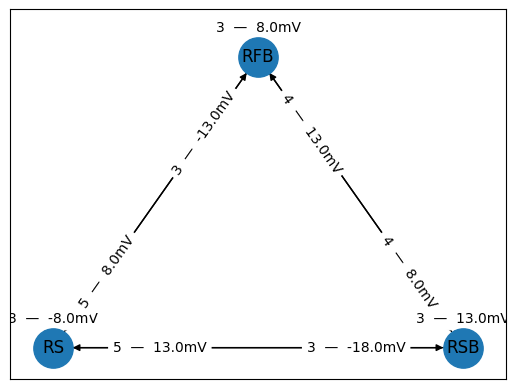

In [4]:
graph1 = nx.DiGraph(best_solution[0, -3:, -3:])
graph2 = nx.DiGraph(best_solution[1, -3:, -3:])

pos = nx.planar_layout(graph1)
nx.draw_networkx_nodes(graph1, pos, node_size=800)
nx.draw_networkx_edges(graph1, pos, node_size=800, arrows=True)
# nx.draw_networkx_edge_labels(graph1, pos, edge_labels=nx.get_edge_attributes(graph1, 'weight'), label_pos=0.7, verticalalignment='bottom')
# nx.draw_networkx_edge_labels(graph2, pos, edge_labels=nx.get_edge_attributes(graph2, 'weight'), label_pos=0.7, verticalalignment='top')
weight_labels_aux1 = nx.get_edge_attributes(graph1, 'weight')
weight_labels_aux2 = nx.get_edge_attributes(graph2, 'weight')
print(weight_labels_aux1)
print(weight_labels_aux2)
weight_labels = {}
for key, v in weight_labels_aux1.items():
    weight_labels[key] = f"{int(weight_labels_aux2[key])}  —  {weight_labels_aux1[key]}mV"
nx.draw_networkx_edge_labels(graph1, pos, edge_labels=weight_labels, label_pos=0.75)
nx.draw_networkx_labels(graph1, pos, labels={0: "RS", 1: "RSB", 2: "RFB"}, )
plt.show()

In [5]:
np.load(f"./solutions/population-{exec_idx}.npy")

array([[ -8., -18., -13.,  13.,  13.,  13.,   8.,   8.,   8.,   3.,   3.,
          3.,   5.,   3.,   4.,   5.,   4.,   3.],
       [  0., -18., -18.,   8.,   8.,   0.,   8.,  13.,  13.,   3.,   3.,
          5.,   3.,   1.,   3.,   5.,   3.,   4.],
       [ -8., -18.,  -8.,  13.,   0.,   0.,   8.,  13.,  13.,   3.,   3.,
          3.,   4.,   3.,   3.,   3.,   4.,   3.],
       [ -8., -13.,  -8.,  13.,   0.,   0.,   8.,  13.,   8.,   3.,   3.,
          3.,   4.,   3.,   3.,   5.,   4.,   3.],
       [ -8., -18.,  -8.,  13.,   0.,   8.,   8.,  13.,  13.,   3.,   3.,
          3.,   4.,   3.,   3.,   5.,   4.,   3.],
       [ -8., -18.,  -8.,  13.,   0.,   0.,   8.,  13.,  13.,   3.,   3.,
          3.,   4.,   3.,   3.,   5.,   4.,   3.],
       [ -8., -13.,  -8.,  13.,   0.,   0.,   8.,  13.,  13.,   3.,   3.,
          3.,   4.,   3.,   3.,   5.,   4.,   3.],
       [ -8., -18.,  -8.,  13.,   0.,   0.,   8.,  13.,  13.,   3.,   3.,
          3.,   4.,   3.,   3.,   5.,   4.,   3.],


time simulator: 71.47332167625427s
time metrics: 0.20107769966125488s
{'Freq': 0.24952767974904647, 'Freq_naive': 0.011311385475049911, 'N_dead_neurons': 9, 'CV': 0.5778219542246232}


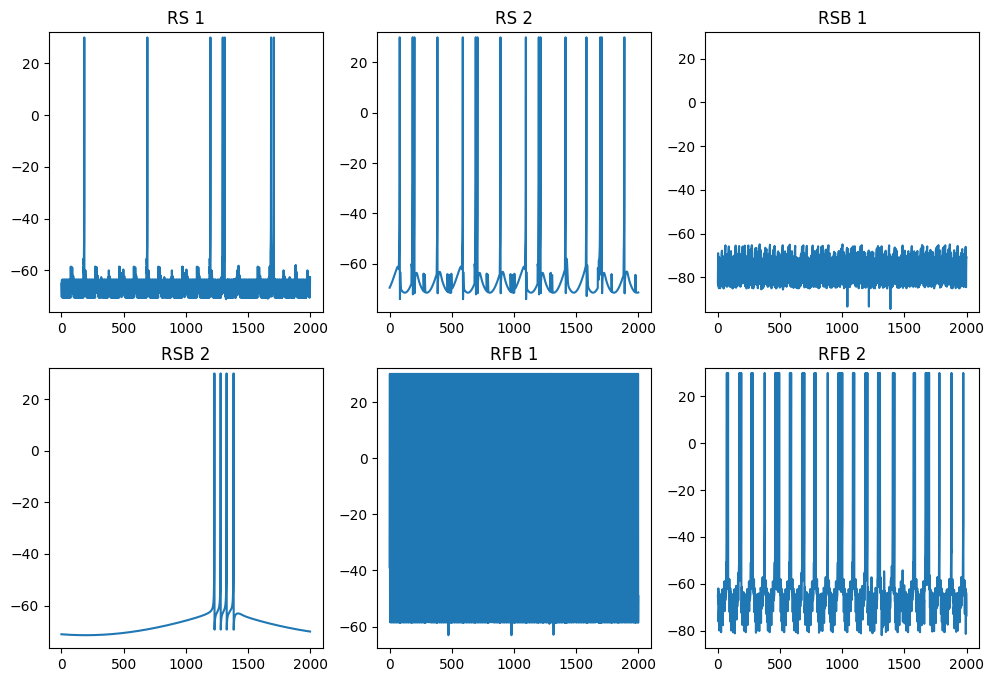

In [6]:
simulation_time = 1000
neuron_amounts = (0, 0, 0, 0, 0, 12, 6, 2)
adj_matrix = best_solution[0]
conn_matrix = best_solution[1]

t0 = time.time()
sim, volt = run_simulator(adj_matrix, conn_matrix, simulation_time=simulation_time, neuron_amounts=neuron_amounts, record_volt=True)
t1 = time.time()
print(f"time simulator: {t1 - t0}s")

t0 = time.time()
metrics = simulator_fn.get_metrics(sim, simulation_time=simulation_time, burst_thesh=0.02)
t1 = time.time()
print(f"time metrics: {t1 - t0}s")

print(metrics)

fig, ax = plt.subplots(2, 3, figsize=(12, 8))
ax_flat = ax.flatten()
idx_list = np.random.permutation(volt.shape[0])[:6]

window = slice(2000,4000)
ax[0, 0].plot(volt[0, window])
ax[0, 1].plot(volt[1, window])
ax[0, 2].plot(volt[14, window])
ax[1, 0].plot(volt[15, window])
ax[1, 1].plot(volt[18, window])
ax[1, 2].plot(volt[19, window])

ax[0, 0].set(title=f"RS 1", ylim=(None, 32))
ax[0, 1].set(title=f"RS 2", ylim=(None, 32))
ax[0, 2].set(title=f"RSB 1", ylim=(None, 32))
ax[1, 0].set(title=f"RSB 2", ylim=(None, 32))
ax[1, 1].set(title=f"RFB 1", ylim=(None, 32))
ax[1, 2].set(title=f"RFB 2", ylim=(None, 32))

plt.show()

In [10]:
n_idx = 0

2314


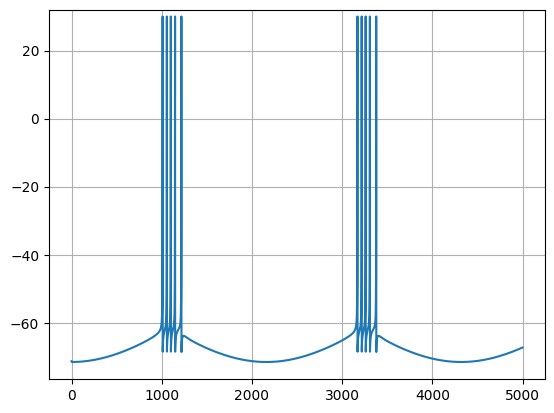

In [27]:
# plt.stem(volt[15, :1000], bottom=-80)
print(np.count_nonzero(np.diff(sim[n_idx]) > 0.02))
plt.plot(volt[n_idx, :5000])
plt.ylim((None, 32))
plt.grid()
plt.show()
n_idx = (n_idx+1) % len(volt)

1 0.009999999999990905 0.6929999999999836


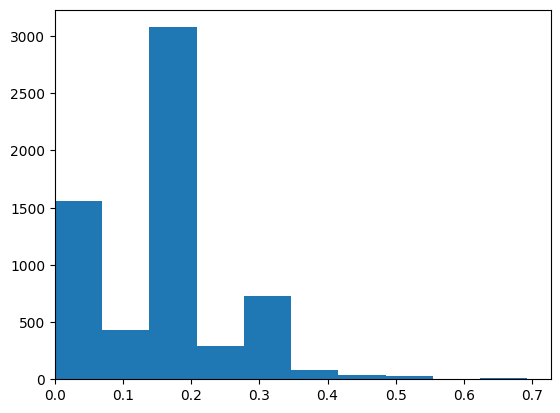

In [9]:
diff_times = np.diff(sim[n_idx])
while len(diff_times) < 1:
    n_idx = (n_idx+1) % len(volt)
    diff_times = np.diff(sim[n_idx])

print(n_idx, min(diff_times), max(diff_times))
plt.hist(np.concatenate((diff_times, [0])))
plt.xlim((0, None))

n_idx = (n_idx+1) % len(volt)